<a href="https://colab.research.google.com/github/Ajay-s2006/AI_Ml-Assigment/blob/main/ai_ml_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
path = kagglehub.dataset_download("patelris/crop-yield-prediction-dataset")

100%|██████████| 959k/959k [00:00<00:00, 67.1MB/s]

Extracting files...


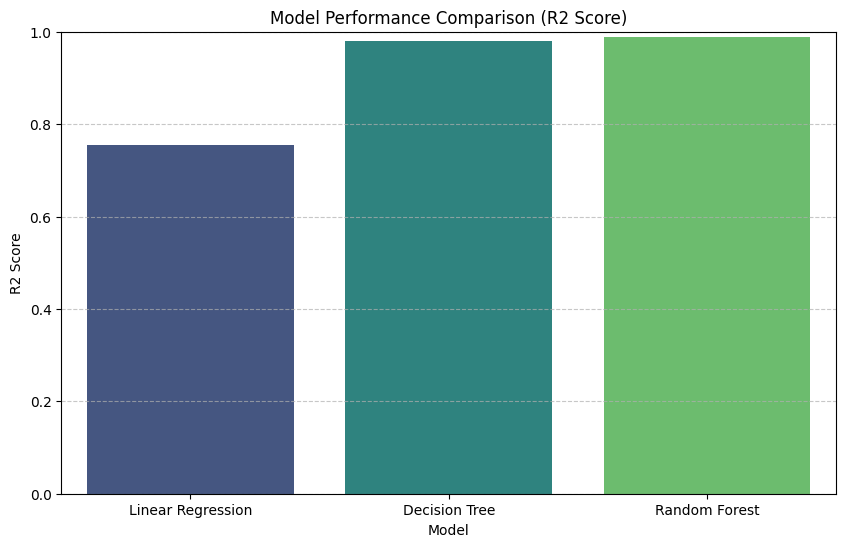

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare data for plotting
r2_scores = {name: metrics['R2 Score'] for name, metrics in results.items()}
performance_df = pd.DataFrame(list(r2_scores.items()), columns=['Model', 'R2 Score'])

# Create the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='R2 Score', data=performance_df, palette='viridis', hue='Model', legend=False)
plt.title('Model Performance Comparison (R2 Score)')
plt.xlabel('Model')
plt.ylabel('R2 Score')
plt.ylim(0, 1) # R2 score typically ranges from 0 to 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Initialize models
linear_model = LinearRegression()
decision_tree_model = DecisionTreeRegressor(random_state=42)
random_forest_model = RandomForestRegressor(random_state=42)

models = {
    'Linear Regression': linear_model,
    'Decision Tree': decision_tree_model,
    'Random Forest': random_forest_model
}

results = {}

# Train and evaluate each model
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = mse**0.5

    results[name] = {'R2 Score': r2, 'MAE': mae, 'MSE': mse, 'RMSE': rmse}

    print(f"{name} - R2 Score: {r2:.4f}")
    print(f"{name} - Mean Absolute Error: {mae:.2f}")
    print(f"{name} - Mean Squared Error: {mse:.2f}")
    print(f"{name} - Root Mean Squared Error: {rmse:.2f}")

print("\n--- Model Performance Summary ---")
for name, metrics in results.items():
    print(f"\n{name}:")
    for metric, value in metrics.items():
        print(f"  {metric}: {value:.4f}")


Training Linear Regression...
Linear Regression - R2 Score: 0.7551
Linear Regression - Mean Absolute Error: 29582.50
Linear Regression - Mean Squared Error: 1776116987.43
Linear Regression - Root Mean Squared Error: 42144.00

Training Decision Tree...
Decision Tree - R2 Score: 0.9796
Decision Tree - Mean Absolute Error: 3655.85
Decision Tree - Mean Squared Error: 147855596.60
Decision Tree - Root Mean Squared Error: 12159.59

Training Random Forest...
Random Forest - R2 Score: 0.9876
Random Forest - Mean Absolute Error: 3474.49
Random Forest - Mean Squared Error: 90181642.98
Random Forest - Root Mean Squared Error: 9496.40

--- Model Performance Summary ---

Linear Regression:
  R2 Score: 0.7551
  MAE: 29582.4950
  MSE: 1776116987.4342
  RMSE: 42144.0030

Decision Tree:
  R2 Score: 0.9796
  MAE: 3655.8506
  MSE: 147855596.6044
  RMSE: 12159.5887

Random Forest:
  R2 Score: 0.9876
  MAE: 3474.4930
  MSE: 90181642.9800
  RMSE: 9496.4016


In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = yield_df_main.drop('hg/ha_yield', axis=1)
y = yield_df_main['hg/ha_yield']

# Identify categorical columns for one-hot encoding
categorical_cols = ['Area', 'Item']

# Apply one-hot encoding
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_encoded_array = encoder.fit_transform(X[categorical_cols])

# Create a DataFrame with the encoded features
X_encoded_df = pd.DataFrame(X_encoded_array, columns=encoder.get_feature_names_out(categorical_cols))

# Drop original categorical columns and concatenate encoded ones
X = X.drop(categorical_cols, axis=1)
X = pd.concat([X.reset_index(drop=True), X_encoded_df], axis=1)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)
print("\nFirst 5 rows of X after encoding:")
print(X.head())

Shape of X_train: (22593, 115)
Shape of X_test: (5649, 115)
Shape of y_train: (22593,)
Shape of y_test: (5649,)

First 5 rows of X after encoding:
   Year  average_rain_fall_mm_per_year  pesticides_tonnes  avg_temp  \
0  1990                         1485.0              121.0     16.37   
1  1990                         1485.0              121.0     16.37   
2  1990                         1485.0              121.0     16.37   
3  1990                         1485.0              121.0     16.37   
4  1990                         1485.0              121.0     16.37   

   Area_Albania  Area_Algeria  Area_Angola  Area_Argentina  Area_Armenia  \
0           1.0           0.0          0.0             0.0           0.0   
1           1.0           0.0          0.0             0.0           0.0   
2           1.0           0.0          0.0             0.0           0.0   
3           1.0           0.0          0.0             0.0           0.0   
4           1.0           0.0          0.0    

In [ ]:
# Drop the 'Unnamed: 0' column as it appears to be an index artifact
yield_df_main = yield_df_main.drop('Unnamed: 0', axis=1)

# Rename 'Area' column in temp_df to 'country' to match yield_df_main for consistency if merging later, though not needed now.
temp_df = temp_df.rename(columns={'country': 'Area'})

# Rename the 'Year' column in temp_df to 'year' for consistency with other dataframes
temp_df = temp_df.rename(columns={'year': 'Year'})

# Clean column name in rainfall_df (remove leading space)
rainfall_df.columns = rainfall_df.columns.str.strip()

# Convert 'average_rain_fall_mm_per_year' to numeric in rainfall_df, coercing errors
rainfall_df['average_rain_fall_mm_per_year'] = pd.to_numeric(rainfall_df['average_rain_fall_mm_per_year'], errors='coerce')

# Impute missing values in rainfall_df and temp_df if we were to use them, but sticking with yield_df_main for now
# For simplicity, if yield_df_main is complete, we'll use it.

# Display info of the cleaned main dataframe
print("\n--- Info for cleaned yield_df_main ---")
yield_df_main.info()
print("\n--- Head of cleaned yield_df_main ---")
print(yield_df_main.head())

# Check unique values in categorical columns to prepare for encoding
print("\nUnique Areas in yield_df_main:", yield_df_main['Area'].nunique())
print("\nUnique Items (Crops) in yield_df_main:", yield_df_main['Item'].nunique())


--- Info for cleaned yield_df_main ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Area                           28242 non-null  object 
 1   Item                           28242 non-null  object 
 2   Year                           28242 non-null  int64  
 3   hg/ha_yield                    28242 non-null  int64  
 4   average_rain_fall_mm_per_year  28242 non-null  float64
 5   pesticides_tonnes              28242 non-null  float64
 6   avg_temp                       28242 non-null  float64
dtypes: float64(3), int64(2), object(2)
memory usage: 1.5+ MB

--- Head of cleaned yield_df_main ---
      Area         Item  Year  hg/ha_yield  average_rain_fall_mm_per_year  \
0  Albania        Maize  1990        36613                         1485.0   
1  Albania     Potatoes  1990        66667               

In [ ]:
print("\n--- Info for pesticides_df ---")
pesticides_df.info()
print("\n--- Info for yield_df_main ---")
yield_df_main.info()
print("\n--- Info for yield_data ---")
yield_data.info()
print("\n--- Info for rainfall_df ---")
rainfall_df.info()
print("\n--- Info for temp_df ---")
temp_df.info()

print("\n--- Shape of pesticides_df ---")
print(pesticides_df.shape)
print("\n--- Shape of yield_df_main ---")
print(yield_df_main.shape)
print("\n--- Shape of yield_data ---")
print(yield_data.shape)
print("\n--- Shape of rainfall_df ---")
print(rainfall_df.shape)
print("\n--- Shape of temp_df ---")
print(temp_df.shape)

# Check for duplicate rows in yield_df_main as it seems like a pre-processed combined dataset
print("\n--- Duplicates in yield_df_main ---")
print(yield_df_main.duplicated().sum())


--- Info for pesticides_df ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4349 entries, 0 to 4348
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Domain   4349 non-null   object 
 1   Area     4349 non-null   object 
 2   Element  4349 non-null   object 
 3   Item     4349 non-null   object 
 4   Year     4349 non-null   int64  
 5   Unit     4349 non-null   object 
 6   Value    4349 non-null   float64
dtypes: float64(1), int64(1), object(5)
memory usage: 238.0+ KB

--- Info for yield_df_main ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     28242 non-null  int64  
 1   Area                           28242 non-null  object 
 2   Item                           28242 non-null  object 
 3   Year       

In [ ]:
import pandas as pd

# Load the datasets
pesticides_df = pd.read_csv(os.path.join(path, 'pesticides.csv'))
yield_df_main = pd.read_csv(os.path.join(path, 'yield_df.csv'))
yield_data = pd.read_csv(os.path.join(path, 'yield.csv')) # another yield file, will check if needed
rainfall_df = pd.read_csv(os.path.join(path, 'rainfall.csv'))
temp_df = pd.read_csv(os.path.join(path, 'temp.csv'))

print("pesticides_df.head():\n", pesticides_df.head())
print("\nyield_df_main.head():\n", yield_df_main.head())
print("\nyield_data.head():\n", yield_data.head())
print("\nrainfall_df.head():\n", rainfall_df.head())
print("\ntemp_df.head():\n", temp_df.head())

pesticides_df.head():
            Domain     Area Element                Item  Year  \
0  Pesticides Use  Albania     Use  Pesticides (total)  1990   
1  Pesticides Use  Albania     Use  Pesticides (total)  1991   
2  Pesticides Use  Albania     Use  Pesticides (total)  1992   
3  Pesticides Use  Albania     Use  Pesticides (total)  1993   
4  Pesticides Use  Albania     Use  Pesticides (total)  1994   

                           Unit  Value  
0  tonnes of active ingredients  121.0  
1  tonnes of active ingredients  121.0  
2  tonnes of active ingredients  121.0  
3  tonnes of active ingredients  121.0  
4  tonnes of active ingredients  201.0  

yield_df_main.head():
    Unnamed: 0     Area         Item  Year  hg/ha_yield  \
0           0  Albania        Maize  1990        36613   
1           1  Albania     Potatoes  1990        66667   
2           2  Albania  Rice, paddy  1990        23333   
3           3  Albania      Sorghum  1990        12500   
4           4  Albania     Soybe

In [ ]:
import os

# List the contents of the downloaded dataset directory
print(os.listdir(path))

['pesticides.csv', 'yield_df.csv', 'yield.csv', 'rainfall.csv', 'temp.csv']
